## **Session 9** - Classification Evaluation Metrics
Evaluation metrics are quantitative measures that assess the performance of classification models, providing insights into their strengths and weaknesses.

ارزیابی مدل فقط در مورد این نیست که بگوییم مدل خوب است یا بد است. یک فرآیند ظریف و جزپی درباره درک جنبه های مختلف مدل است . مانند:
1. دقت کلی
2. عملکرد مدل روی کلاس های مختلف
3. نوانایی مدل برای هندل کردن داده های نامتعادل (مثلا فرض کنید دیتا ستی داریم حاوی یک میلیون عکس سگ و تنها هزار عکس گربه)
4. Robustness across different thresholds
5. توانایی تعمیم به داده های دیده نشده

![](images/img_25.png)

فرض کنید مدلی برای تشخیص یک بیماری نادر که تنها ۱ درصد از جمعیت را درگیر می‌کند، توسعه داده‌اید. اگر مدل شما برای تمام بیماران صرفاً پیش‌بینی کند که «بیماری وجود ندارد»، در ۹۹ درصد موارد درست عمل کرده است! با این حال، چنین مدلی برای هدف اصلی خود عملاً بی‌فایده است. این مثال نشان می‌دهد که چرا معیار «دقت» $(Accuracy)$ به‌تنهایی اغلب کافی نیست و چرا به مجموعه‌ای جامع‌تر از معیارهای ارزیابی نیاز داریم.

Evaluation is not a one-time step at the end of model development. It's an integral part of the entire machine learning pipeline:

1. **During Model Selection:** Evaluation metrics guide us in choosing between different algorithms or model architectures.
2. **During Hyperparameter Tuning:** We use evaluation metrics to fine-tune our models and find the best configuration.
3. **For Model Validation:** Evaluation on a held-out test set helps us estimate how well our model will perform on unseen data.
4. **In Production Monitoring:** Ongoing evaluation ensures our deployed model continues to perform well over time.

---

The process of evaluating a classification model typically involves the following steps:

1. **Split the Data:** Divide your dataset into training, validation, and test sets.
2. **Train the Model:** Use the training data to build your model.
3. **Make Predictions**: Use your model to make predictions on the validation or test set.
4. **Compare Predictions:** Compare these predictions to the true labels.
5. **Calculate Metrics:** Compute various evaluation metrics based on this comparison.
6. **Interpret Results:** Analyze these metrics to understand model performance.
7. **Iterate:** Use insights from evaluation to improve your model if necessary.

---

While evaluation might seem straightforward, several challenges can complicate the process:

- **Class Imbalance:** When some classes are much more frequent than others, many metrics can be misleading.
- **Multi-class Problems:** Some metrics designed for binary classification don't extend easily to multi-class scenarios.
- **Probabilistic Outputs:** Many models output probabilities rather than hard classifications, requiring threshold-based metrics.
- **Cost-sensitive Classification:** In some domains, different types of errors have vastly different consequences.




### Confusion Matrix: The Foundation of Classification Metrics
A confusion matrix is a table that allows visualization of a classification model's performance. For a binary classification problem, it's typically a 2x2 matrix:

![](images/img_26.png)

Where:

- TN (True Negative): Correctly predicted negative class
- FP (False Positive): Incorrectly predicted positive class
- FN (False Negative): Incorrectly predicted negative class
- TP (True Positive): Correctly predicted positive class

---

این جدول نشان میدهد در چه حالت هایی مدل ما عملکرد درستی داشته است.
درواقع، «عملکرد درست» یعنی جایی که مدل به درستی مثبت بودن را پیش بینی کرده یا جایی که به درستی منفی بودن را پیش بینی کرده

برای مثال، در پیش بینی اینکه آیا فردی سرطان دارد یا ندارد :
- فرد سرطان دارد و مدل این را فهمیده
- فرد سرطان ندارد و مدل این را متوجه نشده و پیش بینی آن می گوید که فرد سرطان دارد

در حالت هایی غیر از این دو مدل عملکرد درستی ندارد.

البته بررسی تعداد و حجم پیش بینی های نادرست هم مهم است.

برای مثال در همین پیش بینی سرطان، اگر اشتباها پیش بینی کنیم که فرد سرطان دارد شاید چندان اتفاق مهمی رخ ندهد. اما اگر اشتباها به فرد بگوییم سرطان ندارد میتواند به یک فاجعه ختم شود.

---

#### Constructing a Confusion Matrix
Let's walk through the process of creating a confusion matrix:

Make predictions on your validation or test set.
Compare these predictions to the true labels.
Count the occurrences of each possible outcome (TN, FP, FN, TP).
Organize these counts into the matrix structure.



In [27]:
from sklearn.metrics import confusion_matrix, roc_auc_score  # Import
import numpy as np

import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression


In [53]:
# Load the data
data = load_breast_cancer()
x = data.data
y = data.target

In [54]:
#Split the data into training and testing data
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [30]:
# Train a model
model = LogisticRegression(max_iter=5)
model.fit(X_train, y_train)

C:\Users\ASUS\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 5 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [55]:
y_pred = model.predict(X_test)
y_scores = model.predict_proba(X_test)[:, 1]

In [65]:
y_true = y_test
cm = confusion_matrix(y_true, y_pred)
cm

array([[28, 15],
       [ 0, 71]])

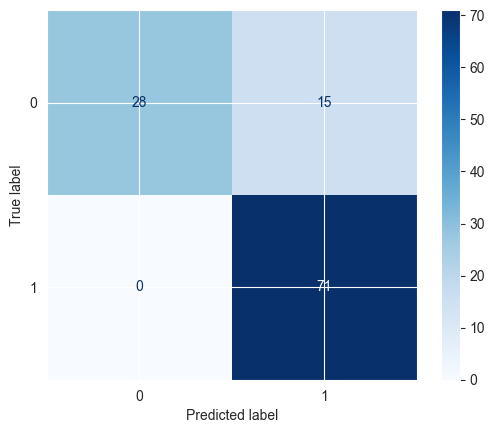

In [66]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_true, y_pred, cmap="Blues")

<Axes: >

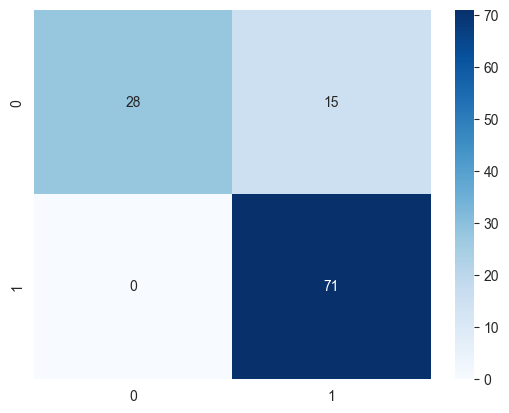

In [67]:
# We can display it with sea born too
import seaborn as sns
sns.heatmap(cm, annot=True, cmap="Blues", fmt='d')

#### Beyond Binary Classification
برای حالت هایی که چند کلاس داری (باینری نیست) ماتریس تشکیل شده از همان قاعده پیروی می کند، با این تفاوت که ماتریس دیگر  ۲*۲ نیست. به ازای $n$ فیچر $n*n$ است.

![](images/img_27.png)



In [69]:
from sklearn.datasets import load_iris

data = load_iris()
X = data.data
y_true_multi = data.target

y_pred_multi = np.random.randint(0, 3, size=len(y_true_multi))

cm = confusion_matrix(y_true_multi, y_pred_multi)
cm

array([[15, 20, 15],
       [18, 21, 11],
       [15, 15, 20]])

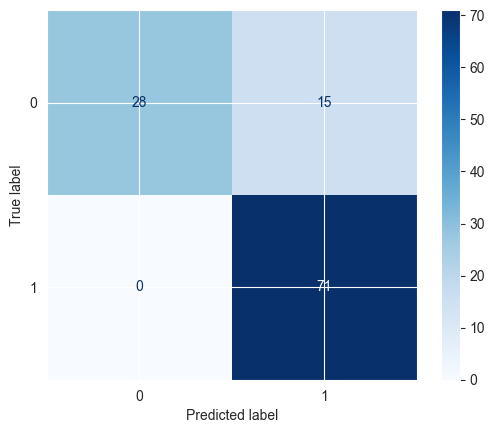

In [70]:
ConfusionMatrixDisplay.from_predictions(y_true, y_pred, cmap="Blues")

<Axes: >

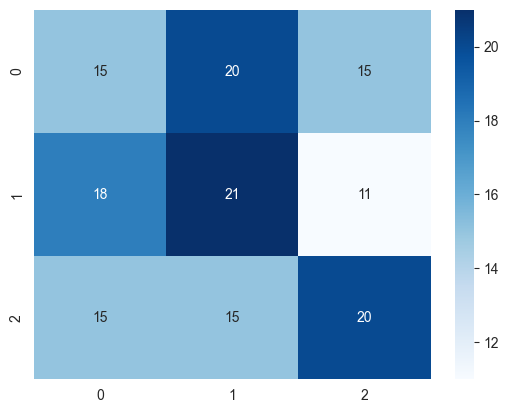

In [71]:
sns.heatmap(cm, annot=True, cmap="Blues", fmt='d')

### **Basic Metrics**: *Accuracy*, *Precision*, and *F1-score*

![](images/img_28.png)

#### Accuracy
دقت، شهودی‌ترین معیار است که نسبت پیش‌بینی‌های صحیح را در میان کل موارد بررسی شده اندازه‌گیری می‌کند.

>Accuracy = (Number of Correct Predictions) / (Total Number of Predictions)

In terms of the confusion matrix:

$Accuracy = \frac{TP + TN}{TP + TN + FP + FN}$

این شیوه اگرچه راحت و بدیهی است، اما در بسیاری موارد قابل استناد نیست

برای مثال فرض کنید می خواهیم مدلی بسازیم که درمورد یک بیماری که تنها ۱٪ مردم به آن مبتلا می شوند پیش بینی انجام دهد. اگر مدل ما همه افراد را پاک و فاقد بیماری تشخیص دهد دقت ۹۹٪ دریافت خواهد کرد. ولی درواقع مدل اصلا عملکرد درستی ندارد

در واقع، معیار «دقت» برای داده های نامتعادل معیار خوبی نیست


In [72]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_true, y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 0.868421052631579


#### Precision: Focus on False Positive

Precision measures the accuracy of positive predictions. It's the ratio of correctly predicted positive examples to the total predicted positive examples.

$Precision = \frac{TP}{TP + FP}$

Precision is particularly useful when the cost of false positives is high.

In [74]:
from sklearn.metrics import precision_score

precision = precision_score(y_true, y_pred)
print(f"Precision: {precision}")

Precision: 0.8255813953488372


#### Recall: Focus on False Negative
Recall, also known as sensitivity or true positive rate, measures the proportion of actual positive cases that were correctly identified.

$Recall = \frac{TP}{TP + FN}$

Recall is crucial when the cost of false negatives is high. In medical diagnosis

In [76]:
from sklearn.metrics import recall_score

recall = recall_score(y_true, y_pred)
print(f"Recall: {recall:.2f}")

Recall: 1.00


![](images/img_29.png)



#### F1-Score: Balancing Precision and Recall
The F1-score is the harmonic mean of precision and recall, providing a single score that balances both metrics.

$F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}$


The F1-score is particularly useful when you have an uneven class distribution

In [77]:
from sklearn.metrics import f1_score

f1 = f1_score(y_true, y_pred)
print(f"F1-score: {f1:.2f}")

F1-score: 0.90


#### When to Use Each Metric

![](images/img_30.png)

![](images/img_31.png)

![](images/img_32.png)

![](images/img_33.png)

---

- **Accuracy:** Best when the classes are balanced and all misclassifications have similar cost.
- **Precision:** Use when the cost of false positives is high.
- **Recall:** Use when the cost of false negatives is high.
- **F1-Score:** Use when you need to balance precision and recall, especially with imbalanced datasets.

---

#### Limitations
- **Threshold Dependency:** For models that output probabilities, these metrics depend on the chosen classification threshold.
- **Class Imbalance:** In highly imbalanced datasets, even these metrics can be misleading.
- **Equal Error Costs:** These metrics assume that all types of errors are equally costly, which isn't always true in practice.



### Advanced metrics: ROC Curve and AUC
![](images/img_34.png)

The ROC curve is a graphical plot that illustrates the diagnostic ability of a binary classifier system as its discrimination threshold is varied. It's created by plotting the True Positive Rate (TPR) against the False Positive Rate (FPR) at various threshold settings.

- True Positive Rate (TPR) = Recall = $\frac{TP}{TP + FN}$

- False Positive Rate (FPR) = $\frac{FP}{FP + TN}$

The ROC curve starts at the point (0,0) and ends at (1,1). A perfect classifier would reach the top-left corner of the plot (0,1), representing 100% TPR and 0% FPR.

To create an ROC curve:

1. For each possible threshold:
    - Calculate the TPR and FPR
    - Plot these values as a single point
2. Connect these points to form the curve



In [78]:
from sklearn.metrics import roc_curve, auc #Import


In [79]:
fpr, tpr, threshold = roc_curve(y_true, y_scores)

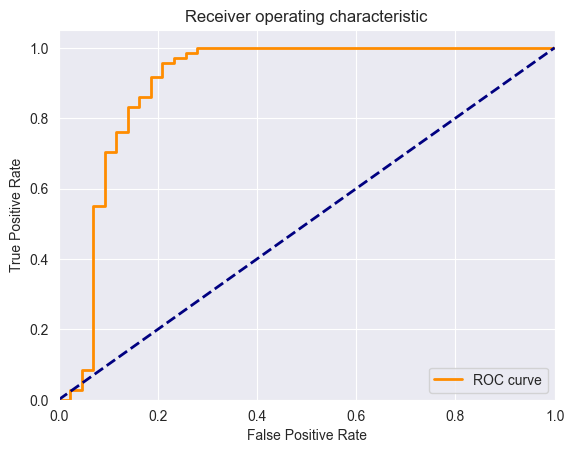

In [80]:
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve',)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")
plt.show()

In [82]:
threshold

array([           inf, 8.42317447e-01, 7.82316602e-01, 7.78008790e-01,
       7.72733722e-01, 7.60519794e-01, 6.87652632e-01, 6.87571704e-01,
       6.59893221e-01, 6.57982394e-01, 6.50286397e-01, 6.48869031e-01,
       6.43320799e-01, 6.40265603e-01, 6.30707048e-01, 6.29851037e-01,
       6.21101392e-01, 6.14515410e-01, 5.96530306e-01, 5.84480149e-01,
       5.83437853e-01, 5.75713383e-01, 5.75429569e-01, 5.67061878e-01,
       5.57752826e-01, 8.80724638e-05])

In [83]:
fpr

array([0.        , 0.02325581, 0.02325581, 0.04651163, 0.04651163,
       0.06976744, 0.06976744, 0.09302326, 0.09302326, 0.11627907,
       0.11627907, 0.13953488, 0.13953488, 0.1627907 , 0.1627907 ,
       0.18604651, 0.18604651, 0.20930233, 0.20930233, 0.23255814,
       0.23255814, 0.25581395, 0.25581395, 0.27906977, 0.27906977,
       1.        ])

In [84]:
tpr

array([0.        , 0.        , 0.02816901, 0.02816901, 0.08450704,
       0.08450704, 0.54929577, 0.54929577, 0.70422535, 0.70422535,
       0.76056338, 0.76056338, 0.83098592, 0.83098592, 0.85915493,
       0.85915493, 0.91549296, 0.91549296, 0.95774648, 0.95774648,
       0.97183099, 0.97183099, 0.98591549, 0.98591549, 1.        ,
       1.        ])

#### Interpreting the ROC Curve

![](images/img_35.png)

---

### Area Under the Curve (AUC)

AUC ranges from 0 to 1, where:

- AUC = 0.5 represents a random classifier
- AUC = 1.0 represents a perfect classifier
- AUC < 0.5 represents a classifier performing worse than random guessing


In [86]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_true, y_pred)

print(f"AUC: {auc}")

AUC: 0.8255813953488372
